# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 Major Project**

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships and differences in agricultural performance, and derive evidence-based recommendations.

**Dataset:** `seasonal_agriculture_performance_dataset.csv` 4000 farm records across 8 Indian states, 8 crops, and 3 seasons, covering environmental conditions, resource usage, yield, and economics.

## 1. Setup and Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Understanding

We start by exploring the structure, data types, and basic statistics of the dataset before doing any cleaning.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [3]:
print("Categorical columns and unique values:\n")
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:10]}")

Categorical columns and unique values:

State: 8 unique -> <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
District: 10 unique -> <StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str
Crop: 8 unique -> <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Season: 3 unique -> <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Irrigation_Method: 4 unique -> <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning and Preparation

Checks performed:
- Missing values
- Duplicate records
- Invalid/out-of-range values
- Consistent data types

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Farm_IDs: 0


In [7]:
# Impute missing numeric values with the median WITHIN each season
# (season-wise median is more accurate than a single global median,
# since rainfall/moisture/yield genuinely differ by season)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [8]:
# Sanity check numeric ranges for obvious data errors
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].agg(['min', 'max']).T

,min,max
Farm_Area_Hectares,0.500,15.00
Rainfall_mm,80.000,1395.20
Avg_Temperature_C,16.200,39.70
Humidity_pct,25.000,95.00
Sunlight_Hours_Day,3.500,11.00
Soil_pH,5.200,8.40
Soil_Moisture_pct,8.000,47.00
Nitrogen_kg_ha,40.000,220.00
Phosphorus_kg_ha,15.000,120.00
Potassium_kg_ha,30.000,200.00


No negative or impossible values found (e.g. yields, costs, revenue, percentages are all within plausible ranges). Data is clean and ready for analysis.

## 4. Feature Engineering

A couple of derived metrics make seasonal comparison easier.

In [9]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR'] * 100).round(2)
df['Cost_per_Tonne_INR'] = (df['Total_Cost_INR'] / df['Production_Tonnes']).round(2)

df[['Season', 'Profit_Margin_pct', 'Cost_per_Tonne_INR']].head()

,Season,Profit_Margin_pct,Cost_per_Tonne_INR
0,Kharif,-38.47,32816.92
1,Kharif,-1118.66,251199.49
2,Rabi,-65.49,124588.93
3,Kharif,-47.68,35802.42
4,Zaid,-74.56,36339.68


## 5. Seasonal Overview

### 5.1 Record distribution across seasons

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


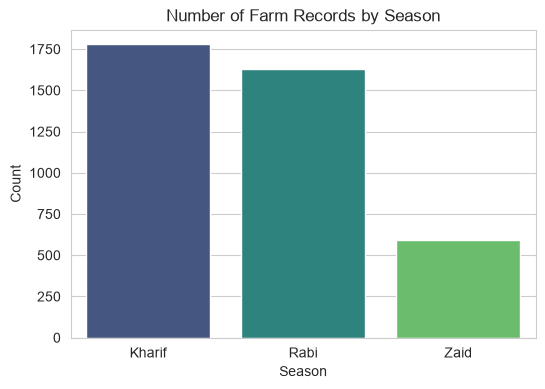

In [21]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis',hue=season_counts.index,legend=False)
plt.title('Number of Farm Records by Season')
plt.ylabel('Count')
plt.xlabel('Season')
plt.show()

### 5.2 Key performance metrics by season

In [11]:
season_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Avg_Total_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Profit_Margin_pct=('Profit_Margin_pct', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)

season_summary

,Avg_Yield_t_ha,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Fertilizer_kg_ha,Avg_Total_Cost_INR,Avg_Revenue_INR,Avg_Profit_INR,Avg_Profit_Margin_pct,Avg_Disease_Risk_pct
Season,,,,,,,,,,,
Kharif,5.63,852.11,28.45,6102.20,5.89,187.08,531804.41,710719.06,178914.65,-38.64,54.47
Rabi,5.04,435.94,23.49,5846.99,5.19,185.41,513836.58,601526.05,87689.47,-44.27,40.48
Zaid,4.64,299.12,31.04,6419.89,4.41,184.64,543976.73,519171.90,-24804.82,-69.35,38.22


## 6. Yield Comparison Across Seasons

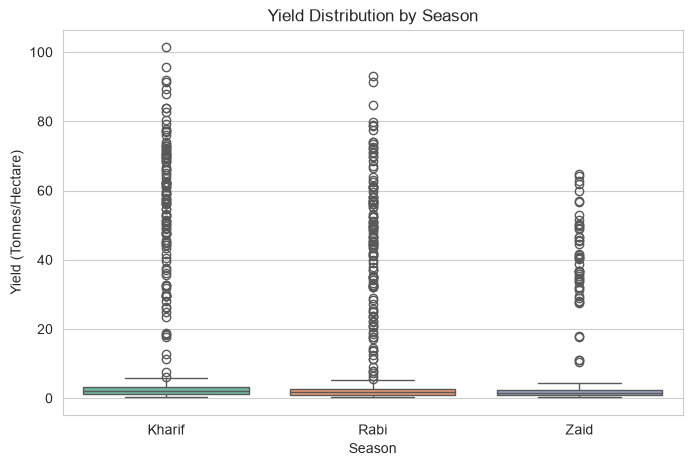

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2',hue='Season',legend=False)
plt.title('Yield Distribution by Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()

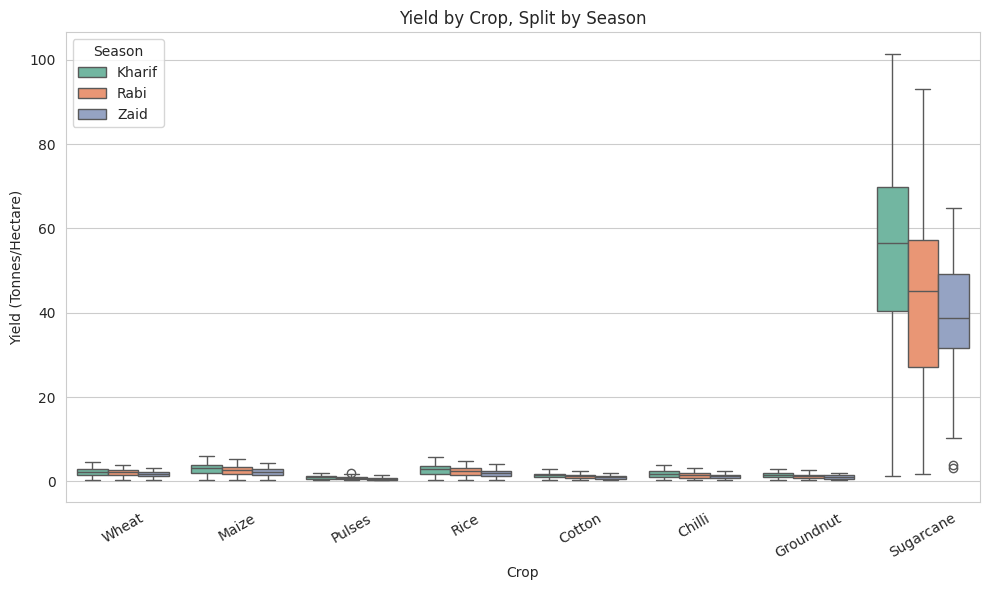

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='Set2')
plt.title('Yield by Crop, Split by Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**ANOVA test** : is the difference in mean yield across seasons statistically significant?

In [14]:
groups = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")
print("Significant seasonal difference in yield" if p_val < 0.05 else "No significant seasonal difference in yield")

F-statistic: 1.554, p-value: 0.21156
No significant seasonal difference in yield


## 7. Environmental Conditions Across Seasons

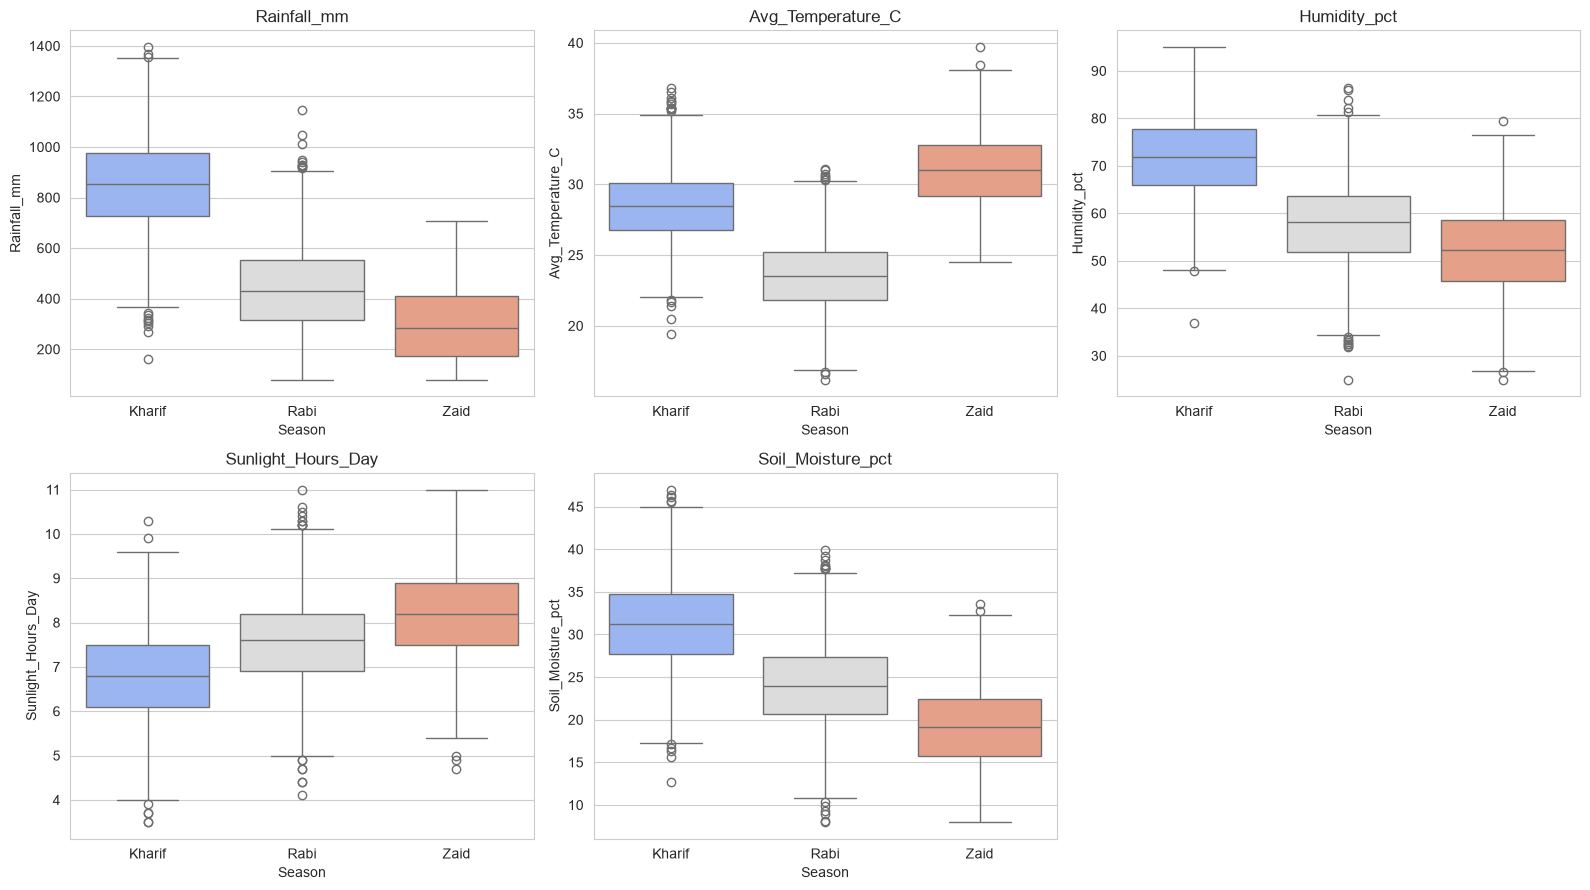

In [ ]:
env_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(
        data=df,
        x='Season',
        y=col,
        hue='Season',
        palette='coolwarm',
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 8. Resource Usage Across Seasons

Comparing water, fertilizer, and pesticide usage and how efficiently water is converted into yield.

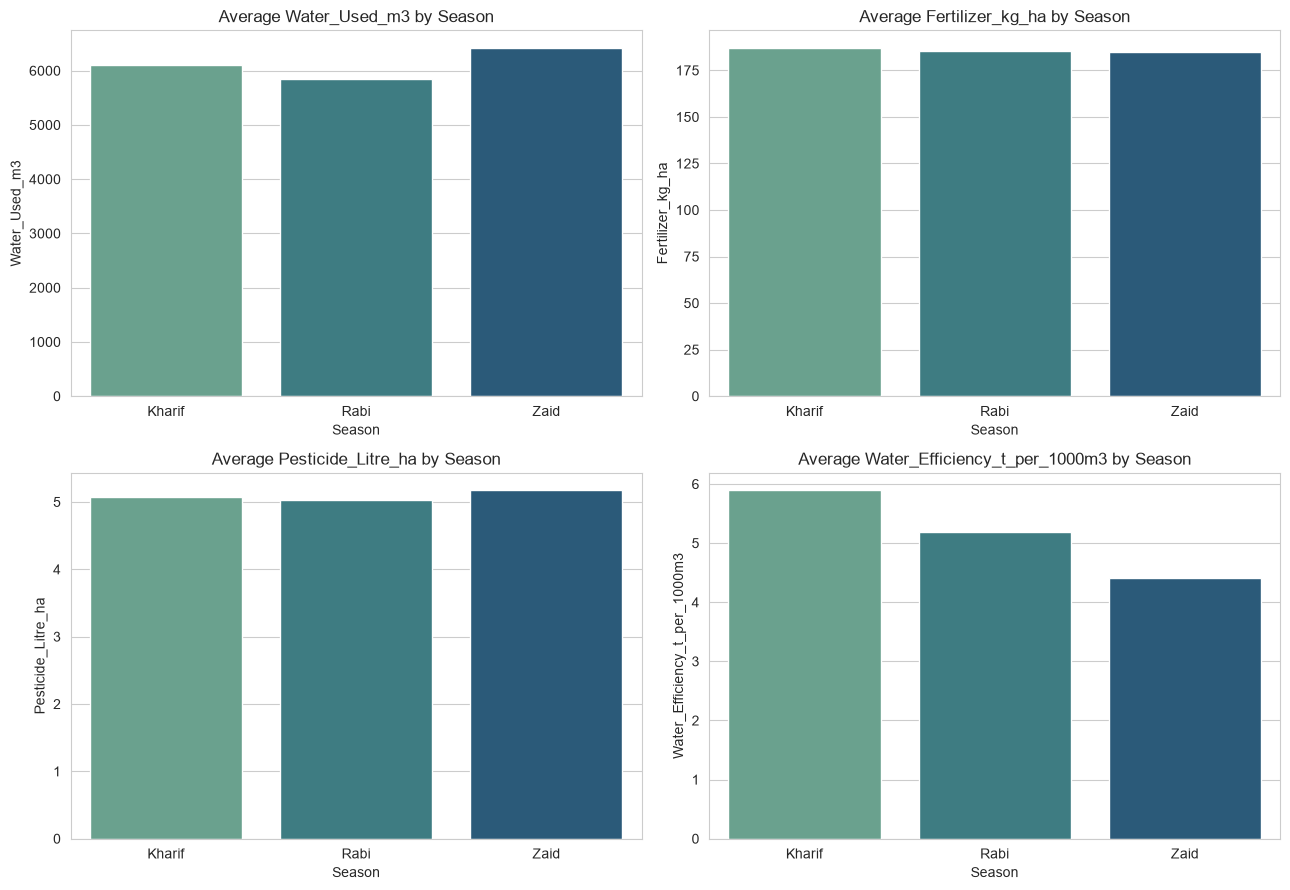

In [6]:
resource_cols = ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x='Season', y=col, ax=axes[i], hue='Season', palette='crest', estimator=np.mean, errorbar=None,legend=False)
    axes[i].set_title(f'Average {col} by Season')
plt.tight_layout()
plt.show()

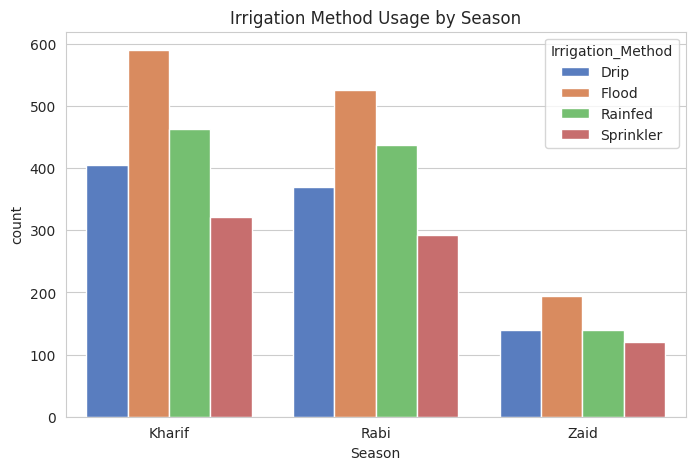

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Season', hue='Irrigation_Method', palette='muted')
plt.title('Irrigation Method Usage by Season')
plt.show()

## 9. Economic Performance Across Seasons

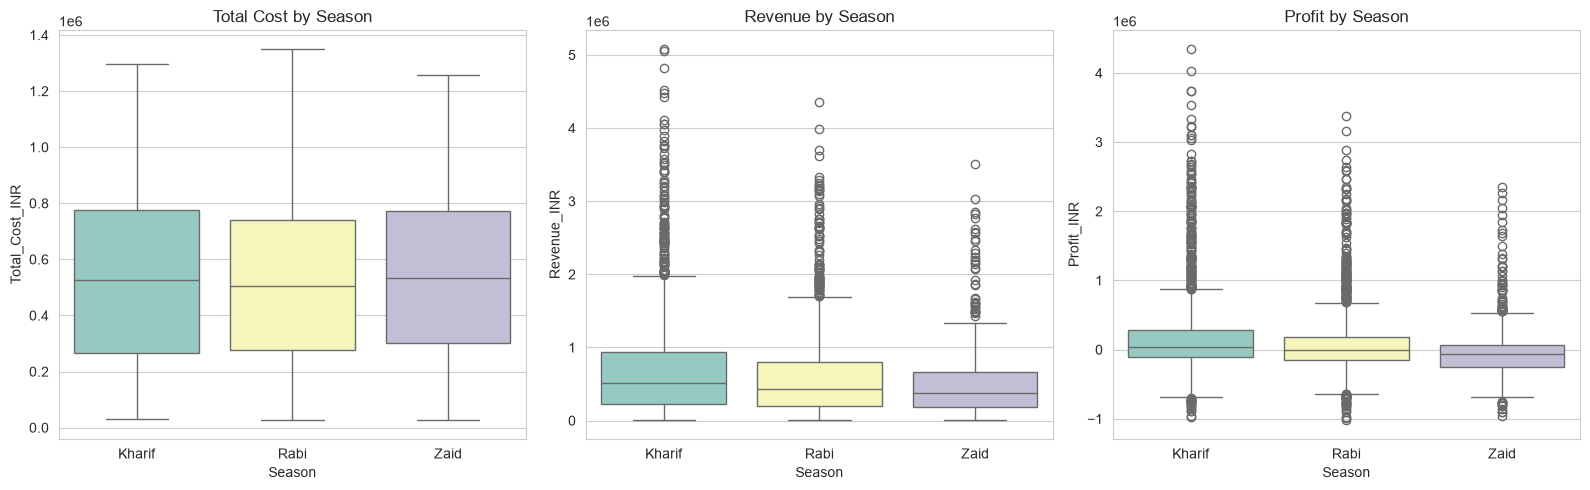

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.boxplot(data=df, x='Season', y='Total_Cost_INR', ax=axes[0], hue='Season',legend=False,palette='Set3')
axes[0].set_title('Total Cost by Season')
sns.boxplot(data=df, x='Season', y='Revenue_INR', ax=axes[1], hue='Season',legend=False,palette='Set3')
axes[1].set_title('Revenue by Season')
sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[2], hue='Season',legend=False,palette='Set3')
axes[2].set_title('Profit by Season')
plt.tight_layout()
plt.show()

In [15]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

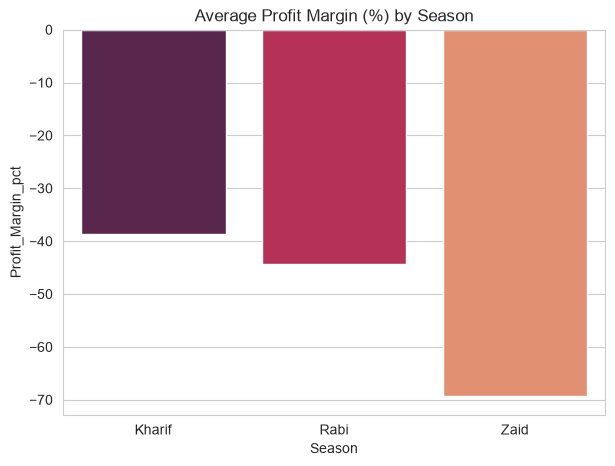

In [17]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Season', y='Profit_Margin_pct', palette='rocket', errorbar=None,hue='Season',legend=False)
plt.title('Average Profit Margin (%) by Season')
plt.show()

## 10. Correlation Analysis

Which environmental and resource factors are most correlated with yield and profit?

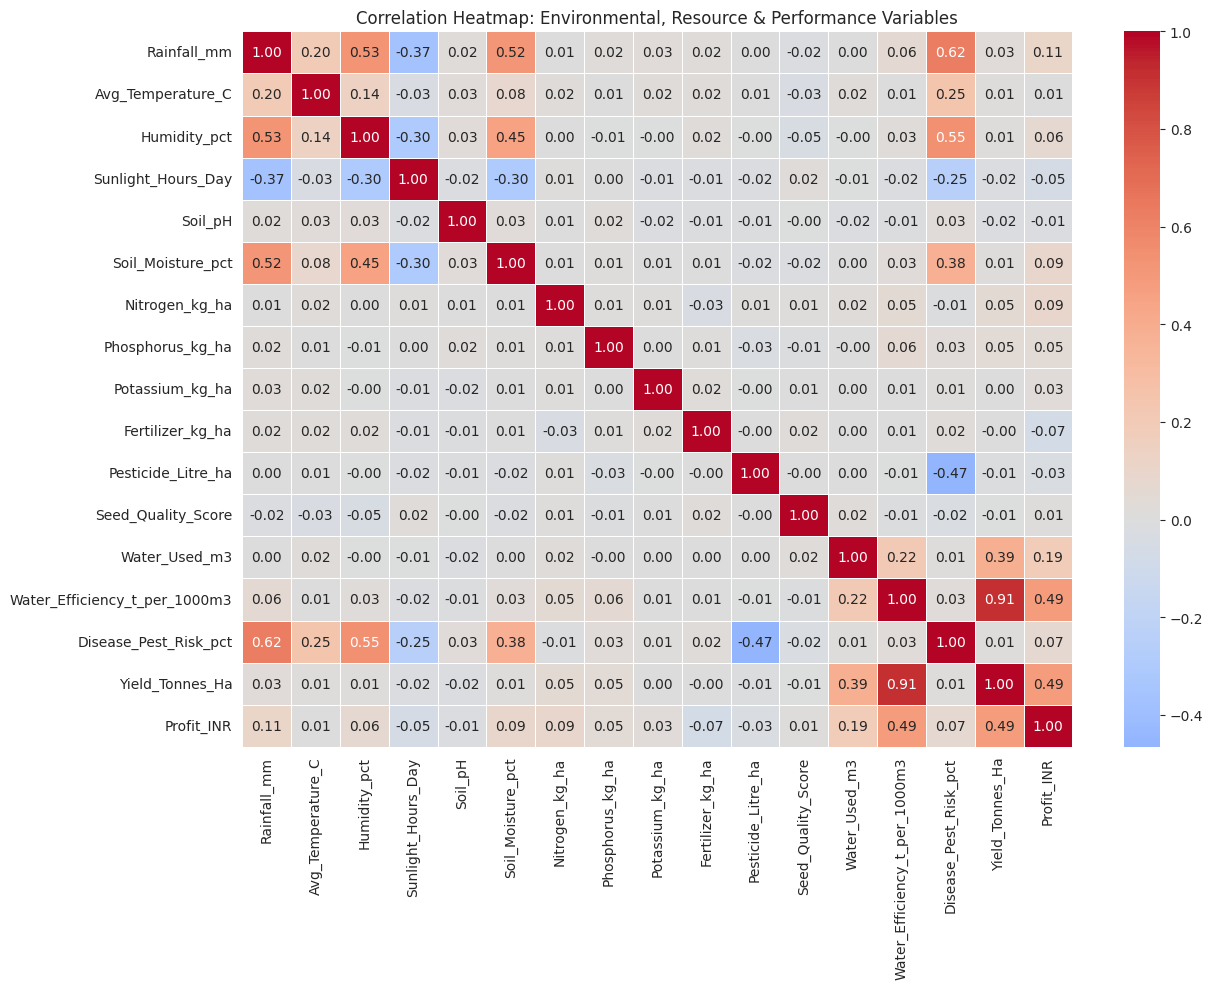

In [20]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
             'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
             'Yield_Tonnes_Ha', 'Profit_INR']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Environmental, Resource & Performance Variables')
plt.tight_layout()
plt.show()

In [21]:
print("Top correlations with Yield:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:6])
print("\nTop correlations with Profit:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False)[1:6])

Top correlations with Yield:
Water_Efficiency_t_per_1000m3    0.912561
Profit_INR                       0.488459
Water_Used_m3                    0.386298
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488459
Water_Used_m3                    0.190278
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.092436
Name: Profit_INR, dtype: float64


## 11. Are Seasonal Patterns Consistent Across Regions?

In [22]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


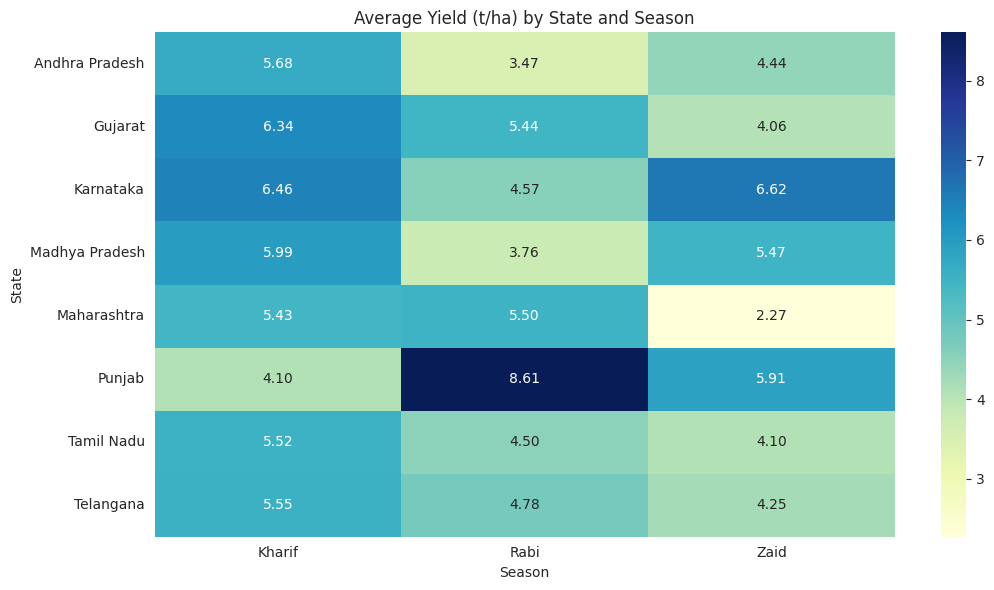

In [23]:
plt.figure(figsize=(11,6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield (t/ha) by State and Season')
plt.tight_layout()
plt.show()

## 12. Disease and Pest Risk by Season

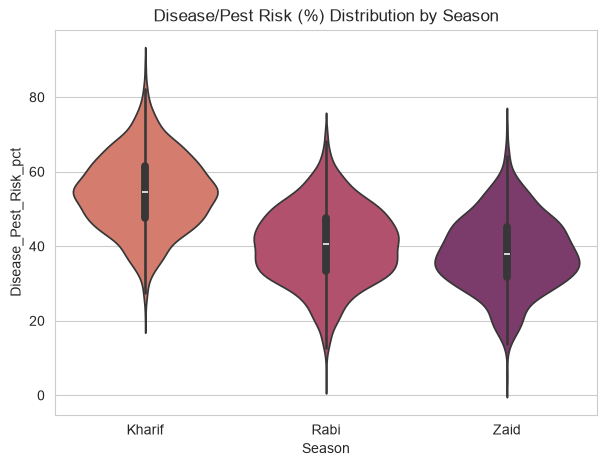

In [12]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Season', palette='flare', legend=False)
plt.title('Disease/Pest Risk (%) Distribution by Season')
plt.show()

## 13. Key Insights

1. **Yield differs numerically across seasons but not statistically significantly.** Kharif has the highest average yield (5.63 t/ha), followed by Rabi (5.04 t/ha) and Zaid (4.64 t/ha), but the ANOVA test gives p ≈ 0.21 (> 0.05)  so this difference could plausibly be due to random variation rather than a true seasonal effect in this dataset.
2. **Water efficiency is the strongest driver of yield** (correlation ≈ 0.91 with Yield_Tonnes_Ha), far ahead of any other factor much stronger than rainfall, nutrients, or pesticide use. Profit also correlates moderately with yield (≈ 0.49).
3. **Water efficiency itself varies by season**: Kharif is most water-efficient (5.89 t per 1000 m³), Zaid the least (4.41) Zaid crops get less yield per unit of water used.
4. **Profit margins are negative across all seasons** in this dataset (Kharif -38.6%, Rabi -44.3%, Zaid -69.3%) average costs exceed average revenue in every season, with Zaid being the worst. This is a notable/unusual finding worth flagging rather than glossing over it may reflect small-farm economics, input costs, or how costs/prices were simulated in this dataset.
5. **Disease/pest risk is highest in Kharif** (54.5%) and lowest in Zaid (38.2%), consistent with Kharif's higher humidity and rainfall.
6. **Seasonal yield ranking is not consistent across states.** E.g., Punjab performs best in Rabi (8.61 t/ha) while most other states peak in Kharif; Maharashtra's Zaid yield (2.27 t/ha) is far below its Kharif/Rabi yields. This means season-level averages hide important regional variation.

## 14. Recommendations

1. Because water efficiency is the dominant driver of yield (not rainfall or fertilizer), prioritize investment in efficient irrigation (drip/sprinkler) over simply increasing fertilizer/pesticide input.
2. Investigate the cost structure behind negative profit margins in every season, especially Zaid this looks like a cost or pricing issue independent of yield, and needs its own analysis (e.g. breaking down Total_Cost_INR by category if more granular data is available).
3. Target disease/pest management resources more heavily in Kharif, where risk is highest.
4. Don't apply a single national seasonal recommendation plan season choice per state (e.g. Punjab's Rabi advantage vs. most other states' Kharif advantage).
5. Given the yield difference across seasons isn't statistically significant here, avoid over-claiming a strong "best season" effect frame it as a mild trend rather than a proven seasonal law, and suggest collecting more years of data to confirm.

## 15. Conclusion

This analysis shows that in this dataset, agricultural yield varies modestly across seasons but not to a statistically significant degree, while water efficiency is by far the strongest measurable driver of yield. All three seasons show negative average profit margins, with Zaid faring worst on both yield and profitability. Seasonal patterns are not uniform across states some (like Punjab) favor Rabi while most favor Kharif so seasonal agricultural planning should be state-specific rather than applying one national rule, and should prioritize irrigation efficiency and cost investigation over broad seasonal assumptions.